In [ ]:
import numpy as np
import xarray as xr
from datetime import datetime , timedelta
import matplotlib.pyplot as plt
import netCDF4
from weatherbenchX.metrics import probabilistic
import apache_beam as beam
import logging
import os
from weatherbenchX.data_loaders import xarray_loaders
from weatherbenchX import aggregation, weighting, binning, beam_pipeline

: 

In [ ]:
# !pip install numpy xarray h5py matplotlib apache-beam 
# !pip install git+https://github.com/google-research/weatherbenchX.git
# !pip install netcdf4

In [ ]:
year = 2018
dates = []
for month in range(1, 13):
    for day in range(1, 32):
        for hour in [0, 6, 12, 18]:
            try:
                date = datetime(year, month, day, hour)
                dates.append(date)
            except ValueError:
                # Skip invalid dates
                continue

dates = np.array(dates)

print(dates)
def find_date_idx(date):
    """
    Find the index of a date string in the dates array.
    """
    try:
        idx = np.where(dates == date)[0][0]
        return idx
    except IndexError:
        return None

IC_idx = find_date_idx(datetime(2018, 6, 30, 0))


[datetime.datetime(2018, 1, 1, 0, 0) datetime.datetime(2018, 1, 1, 6, 0)
 datetime.datetime(2018, 1, 1, 12, 0) ...
 datetime.datetime(2018, 12, 31, 6, 0)
 datetime.datetime(2018, 12, 31, 12, 0)
 datetime.datetime(2018, 12, 31, 18, 0)]


In [ ]:

# Start and end dates
start = datetime(2018, 1, 1, 0, 0)
end = datetime(2018, 12, 31, 23, 59)  # Adjust as needed

# Interval of 6 hours
interval = timedelta(hours=6)

# Generate timestamps
timestamps = []
current = start
while current <= end:
    timestamps.append(current.strftime('%Y%m%d%H'))
    current += interval

# Print or use the timestamps
for ts in timestamps:
    print(ts)

2018010100
2018010106
2018010112
2018010118
2018010200
2018010206
2018010212
2018010218
2018010300
2018010306
2018010312
2018010318
2018010400
2018010406
2018010412
2018010418
2018010500
2018010506
2018010512
2018010518
2018010600
2018010606
2018010612
2018010618
2018010700
2018010706
2018010712
2018010718
2018010800
2018010806
2018010812
2018010818
2018010900
2018010906
2018010912
2018010918
2018011000
2018011006
2018011012
2018011018
2018011100
2018011106
2018011112
2018011118
2018011200
2018011206
2018011212
2018011218
2018011300
2018011306
2018011312
2018011318
2018011400
2018011406
2018011412
2018011418
2018011500
2018011506
2018011512
2018011518
2018011600
2018011606
2018011612
2018011618
2018011700
2018011706
2018011712
2018011718
2018011800
2018011806
2018011812
2018011818
2018011900
2018011906
2018011912
2018011918
2018012000
2018012006
2018012012
2018012018
2018012100
2018012106
2018012112
2018012118
2018012200
2018012206
2018012212
2018012218
2018012300
2018012306
2018012312

In [ ]:
def preprocess_s2s(ds):
    first_date = ds.time[0].values
    times = np.arange(0, len(ds.time) * 24, 24, dtype='timedelta64[h]').astype('timedelta64[ns]')
    ds['time'] = times
    ds = ds.rename({"time": "prediction_timedelta"})
    ds = ds.expand_dims("time")
    ds["time"] = [first_date]
    return ds

ds = None
for ts_idx in range(len(timestamps)):
    ts = timestamps[ts_idx]
    file_base = "/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_{}_ens_*.nc".format(ts)
    ds = xr.open_mfdataset(file_base,combine="nested", concat_dim="number")
    if ts_idx == 0:
        ds_all = preprocess_s2s(ds)
    else:
        ds = preprocess_s2s(ds)
        ds_all = xr.concat([ds, ds_all], dim='time')

    
    

KeyboardInterrupt: 

In [ ]:
ds_all

<xarray.Dataset> Size: 573GB
Dimensions:                                (time: 48, number: 30,
                                            prediction_timedelta: 16, lat: 180,
                                            lon: 360, plev: 17)
Coordinates:
  * prediction_timedelta                   (prediction_timedelta) timedelta64[ns] 128B ...
  * plev                                   (plev) int64 136B 5 10 ... 925 1000
  * lat                                    (lat) float64 1kB -89.5 ... 89.5
  * lon                                    (lon) float64 3kB 0.0 1.0 ... 359.0
  * time                                   (time) datetime64[ns] 384B 2018-01...
Dimensions without coordinates: number
Data variables: (12/16)
    2m_temperature                         (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    10m_u_component_of_wind                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    10m_v_component_of_wind                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    mean_sea_level_pressure                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    surface_pressure                       (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    volumetric_soil_water_layer_1          (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    ...                                     ...
    u_component_of_wind                    (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    v_component_of_wind                    (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    specific_humidity                      (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    geopotential                           (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    total_precipitation_24hr               (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    mean_top_net_long_wave_radiation_flux  (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
Attributes:
    description:  Prediction from pangu_plasim model run 1

In [ ]:
#file = "/project/pedramh/bing/stampede_data/pangu_plasim_2_24h_15step_2018010100_ens_10.nc"
file = "/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_2018010106_ens_*.nc"
#file = "/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/pangu_plasim_8008_24h_45step_2018012000.nc"

In [ ]:
ds_all

<xarray.Dataset> Size: 573GB
Dimensions:                                (time: 48, number: 30,
                                            prediction_timedelta: 16, lat: 180,
                                            lon: 360, plev: 17)
Coordinates:
  * prediction_timedelta                   (prediction_timedelta) timedelta64[ns] 128B ...
  * plev                                   (plev) int64 136B 5 10 ... 925 1000
  * lat                                    (lat) float64 1kB -89.5 ... 89.5
  * lon                                    (lon) float64 3kB 0.0 1.0 ... 359.0
  * time                                   (time) datetime64[ns] 384B 2018-01...
Dimensions without coordinates: number
Data variables: (12/16)
    2m_temperature                         (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    10m_u_component_of_wind                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    10m_v_component_of_wind                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    mean_sea_level_pressure                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    surface_pressure                       (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    volumetric_soil_water_layer_1          (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    ...                                     ...
    u_component_of_wind                    (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    v_component_of_wind                    (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    specific_humidity                      (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    geopotential                           (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    total_precipitation_24hr               (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    mean_top_net_long_wave_radiation_flux  (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
Attributes:
    description:  Prediction from pangu_plasim model run 1

In [ ]:

# ds = xr.open_dataset(file)
# ds = xr.open_mfdataset(file,combine="nested", concat_dim="member")
# temperature_mean = ds["2m_temperature"].mean(dim=["member"])

In [ ]:
# def load_dataset(file):
#     """
#     Load the dataset from the given file path.
#     """
#     try:
#         ds = xr.open_mfdataset(file, combine="nested", concat_dim="member")
#         return ds
#     except Exception as e:
#         print(f"Error loading dataset: {e}")
#         return None



# ds = load_dataset(file )


In [ ]:
ds_all =ds_all.assign_coords(number=("number", ds.number.values))

In [ ]:
ds_all

<xarray.Dataset> Size: 573GB
Dimensions:                                (time: 48, number: 30,
                                            prediction_timedelta: 16, lat: 180,
                                            lon: 360, plev: 17)
Coordinates:
  * prediction_timedelta                   (prediction_timedelta) timedelta64[ns] 128B ...
  * plev                                   (plev) int64 136B 5 10 ... 925 1000
  * lat                                    (lat) float64 1kB -89.5 ... 89.5
  * lon                                    (lon) float64 3kB 0.0 1.0 ... 359.0
  * time                                   (time) datetime64[ns] 384B 2018-01...
  * number                                 (number) int64 240B 0 1 2 ... 28 29
Data variables: (12/16)
    2m_temperature                         (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    10m_u_component_of_wind                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    10m_v_component_of_wind                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    mean_sea_level_pressure                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    surface_pressure                       (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    volumetric_soil_water_layer_1          (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    ...                                     ...
    u_component_of_wind                    (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    v_component_of_wind                    (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    specific_humidity                      (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    geopotential                           (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    total_precipitation_24hr               (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    mean_top_net_long_wave_radiation_flux  (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
Attributes:
    description:  Prediction from pangu_plasim model run 1

In [ ]:
ds_all =ds_all.rename({'lon': 'longitude'}).rename({'lat': 'latitude'}).rename({"plev": "level"})

In [ ]:
ds_all

<xarray.Dataset> Size: 573GB
Dimensions:                                (time: 48, number: 30,
                                            prediction_timedelta: 16, lat: 180,
                                            lon: 360, plev: 17)
Coordinates:
  * prediction_timedelta                   (prediction_timedelta) timedelta64[ns] 128B ...
  * plev                                   (plev) int64 136B 5 10 ... 925 1000
  * lat                                    (lat) float64 1kB -89.5 ... 89.5
  * lon                                    (lon) float64 3kB 0.0 1.0 ... 359.0
  * time                                   (time) datetime64[ns] 384B 2018-01...
  * number                                 (number) int64 240B 0 1 2 ... 28 29
Data variables: (12/16)
    2m_temperature                         (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    10m_u_component_of_wind                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    10m_v_component_of_wind                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    mean_sea_level_pressure                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    surface_pressure                       (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    volumetric_soil_water_layer_1          (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    ...                                     ...
    u_component_of_wind                    (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    v_component_of_wind                    (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    specific_humidity                      (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    geopotential                           (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    total_precipitation_24hr               (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    mean_top_net_long_wave_radiation_flux  (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
Attributes:
    description:  Prediction from pangu_plasim model run 1

In [ ]:
# # ds["2m_temperature"].mean(dim = ["lat","lon"]).plot()
# sub, fig = plt.subplots(1,1, figsize=(8,4))
# temperature_mean[0].plot()

In [ ]:
ds["2m_temperature"][0,29,0,0].values

array([249.54202, 249.5279 , 249.51381, 249.49983, 249.48512, 249.47063,
       249.45618, 249.4413 , 249.4263 , 249.41135, 249.39557, 249.37923,
       249.3628 , 249.34608, 249.32904, 249.31194, 249.29553, 249.27856,
       249.26108, 249.24408, 249.2265 , 249.20824, 249.1887 , 249.16927,
       249.14966, 249.13043, 249.11118, 249.09096, 249.07004, 249.049  ,
       249.02821, 249.0071 , 248.98628, 248.96478, 248.94421, 248.9229 ,
       248.90216, 248.87988, 248.85658, 248.83351, 248.81358, 248.7928 ,
       248.77226, 248.75064, 248.73032, 248.71342, 248.69687, 248.6782 ,
       248.6601 , 248.6423 , 248.62708, 248.6146 , 248.60258, 248.5907 ,
       248.58281, 248.57849, 248.57344, 248.56851, 248.56407, 248.56139,
       248.55908, 248.56192, 248.56694, 248.57509, 248.58675, 248.59813,
       248.6108 , 248.62315, 248.63557, 248.64912, 248.6631 , 248.67912,
       248.69789, 248.7184 , 248.7384 , 248.75851, 248.77837, 248.79909,
       248.82008, 248.84082, 248.85994, 248.87701, 

In [ ]:
obs["2m_temperature"].values

array([[[249.54202, 249.5279 , 249.51381, ..., 249.57681, 249.56543,
         249.55406],
        [250.31921, 250.29225, 250.26436, ..., 250.38734, 250.36551,
         250.34277],
        [250.75403, 250.67699, 250.60336, ..., 250.94852, 250.88684,
         250.82335],
        ...,
        [253.20918, 253.17177, 253.13904, ..., 253.51212, 253.40677,
         253.3015 ],
        [253.82936, 253.80862, 253.79253, ..., 253.97757, 253.92818,
         253.8766 ],
        [253.18854, 253.18895, 253.18848, ..., 253.1981 , 253.19513,
         253.1917 ]],

       [[249.63152, 249.61931, 249.60637, ..., 249.65955, 249.65007,
         249.64091],
        [249.87138, 249.84987, 249.82722, ..., 249.9182 , 249.90283,
         249.88776],
        [250.11797, 250.06427, 250.01233, ..., 250.23169, 250.19699,
         250.16118],
        ...,
        [252.8003 , 252.69197, 252.58298, ..., 253.08237, 252.987  ,
         252.89262],
        [253.29764, 253.27081, 253.24915, ..., 253.45459, 253.40355,
   

In [ ]:
dates_exp = ds["time"].values

In [ ]:
dates_exp 

array(['2018-01-01T00:00:00.000000000'], dtype='datetime64[ns]')

In [ ]:
#Get the string of the ground truth date
# dates_str = []
# for date in dates_exp:
#     dates_str.append(date.astype('datetime64[ms]').astype(object).strftime("%Y%m%d%H"))

In [ ]:
# dates_exp[0].astype('datetime64[ms]').astype(object)

In [ ]:
# Get the index of the ground truth date
# gt_files = []
# for date_exp in dates_exp:
#     date_idx = find_date_idx(date_exp.astype('datetime64[ms]').astype(object))
#     gt_file = "/project/pedramh/h5data/h5data/2018_{:04d}.h5".format(date_idx)
#     gt_files.append(gt_file)
    

In [ ]:
dataset = xr.open_dataset("/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/2018_180x360.nc")
dates_exp

array(['2018-01-01T00:00:00.000000000'], dtype='datetime64[ns]')

In [ ]:
lsm = xr.open_dataset("/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/land_sea_mask_180x360_c.nc")

In [ ]:
lsm = lsm["land_sea_mask"]

In [ ]:
obs = dataset["2m_temperature"]

In [ ]:
obs = obs.rename({'lon': 'longitude'}).rename({'lat': 'latitude'})

In [ ]:
ds_all

<xarray.Dataset> Size: 573GB
Dimensions:                                (time: 48, number: 30,
                                            prediction_timedelta: 16, lat: 180,
                                            lon: 360, plev: 17)
Coordinates:
  * prediction_timedelta                   (prediction_timedelta) timedelta64[ns] 128B ...
  * plev                                   (plev) int64 136B 5 10 ... 925 1000
  * lat                                    (lat) float64 1kB -89.5 ... 89.5
  * lon                                    (lon) float64 3kB 0.0 1.0 ... 359.0
  * time                                   (time) datetime64[ns] 384B 2018-01...
  * number                                 (number) int64 240B 0 1 2 ... 28 29
Data variables: (12/16)
    2m_temperature                         (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    10m_u_component_of_wind                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    10m_v_component_of_wind                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    mean_sea_level_pressure                (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    surface_pressure                       (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    volumetric_soil_water_layer_1          (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    ...                                     ...
    u_component_of_wind                    (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    v_component_of_wind                    (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    specific_humidity                      (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    geopotential                           (time, number, prediction_timedelta, plev, lat, lon) float32 102GB dask.array<chunksize=(1, 1, 16, 17, 180, 360), meta=np.ndarray>
    total_precipitation_24hr               (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
    mean_top_net_long_wave_radiation_flux  (time, number, prediction_timedelta, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 16, 180, 360), meta=np.ndarray>
Attributes:
    description:  Prediction from pangu_plasim model run 1

In [ ]:
obs.isnull().any()

<xarray.Dataset> Size: 1B
Dimensions:         ()
Data variables:
    2m_temperature  bool 1B False

In [146]:
ds_all["2m_temperature"][:10]

<xarray.DataArray '2m_temperature' (time: 10, number: 30,
                                    prediction_timedelta: 16, lat: 180, lon: 360)> Size: 1GB
dask.array<getitem, shape=(10, 30, 16, 180, 360), dtype=float32, chunksize=(1, 1, 16, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 128B 0 days ...
  * lat                   (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                   (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                  (time) datetime64[ns] 80B 2018-01-12T18:00:00 ... 2...
  * number                (number) int64 240B 0 1 2 3 4 5 ... 24 25 26 27 28 29

In [53]:
init_times=ds.time.values

In [54]:
lead_times = ds.prediction_timedelta.values

In [56]:
from weatherbenchX import time_chunks
times = time_chunks.TimeChunks(
  init_times,
  lead_times,
  init_time_chunk_size=1,
  lead_time_chunk_size=1
)
next(iter(times))

(array(['2018-01-01T00:00:00.000000000'], dtype='datetime64[ns]'),
 array([0], dtype='timedelta64[ns]'))

In [61]:
obs = obs.to_dataset()

In [1]:
data_loaders = {
'predictions_loader': xarray_loaders.PredictionsFromXarray(ds=ds_all.isel(time=slice(0,2)), variables=["2m_temperature"]),
'targets_loader': xarray_loaders.TargetsFromXarray(ds=obs, variables=["2m_temperature"]),
}
metrics = {'crps': probabilistic.CRPSEnsemble()}
regions = {
'global': ((-90, 90), (0, 360)),

}
aggregator = aggregation.Aggregator(
reduce_dims=['init_time', 'latitude', 'longitude'],
bin_by=[binning.Regions(regions), binning.LandSea(lsm.compute(), include_global_mask=True)],
weigh_by=[weighting.GridAreaWeighting()],
skipna=True,
)

root = beam.Pipeline(runner='DirectRunner')
beam_pipeline.define_pipeline(
root=root,
times=times,
metrics=metrics,
aggregator=aggregator,
out_path="test.nc",
**data_loaders
)
root.run()

#"SpreadSkillRatio": probabilistic.SpreadSkillRatio()
#'tropics': ((-30, 30), (0, 360)),
# 'extra_tropics_nh': ((30, 60), (0, 360)),
# 'africa': ((-35, 35), (-20, 55)),
# 'india': ((5, 30), (65, 100)),

NameError: name 'xarray_loaders' is not defined

In [126]:
eval_metric = xr.open_dataset("test.nc")

In [131]:
eval_metric

<xarray.Dataset> Size: 4kB
Dimensions:                          (lead_time: 16, region: 5, land_sea: 3)
Coordinates:
  * lead_time                        (lead_time) timedelta64[ns] 128B 0 days ...
  * region                           (region) object 40B 'global' ... 'india'
  * land_sea                         (land_sea) object 24B 'land' 'sea' 'global'
Data variables:
    crps.2m_temperature              (lead_time, region, land_sea) float64 2kB ...
    SpreadSkillRatio.2m_temperature  (lead_time, region, land_sea) float64 2kB ...

In [127]:
eval_metric["SpreadSkillRatio.2m_temperature"].values.shape

(16, 5, 3)

In [71]:
ds["2m_temperature"].to_dataset

<bound method DataArray.to_dataset of <xarray.DataArray '2m_temperature' (member: 30, time: 16, lat: 180, lon: 360)> Size: 124MB
dask.array<concatenate, shape=(30, 16, 180, 360), dtype=float32, chunksize=(1, 16, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 128B 2018-01-01T06:00:00 ... 2018-01-16T06...
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Dimensions without coordinates: member>

In [22]:
#Get the ground truth files
# Open file in read-only mode
lead_time = 0
rmse_ens = []
for lead_time in range(0, 15):
    print("lead_time", lead_time)
    # Open the file
    fcst = temperature_mean[lead_time].values
    # print("fcst shape:", fcst)
    gt = dataset.sel(time=dates_exp[lead_time])["2m_temperature"].values
    # print("gt shape:", gt)
    rmse = np.sqrt(np.mean((fcst - gt) ** 2))
    print("RMSE:", rmse)
    rmse_ens.append(rmse)


lead_time 0


NameError: name 'temperature_mean' is not defined

/home/gongbing/ipykernel_2598854/2257184255.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


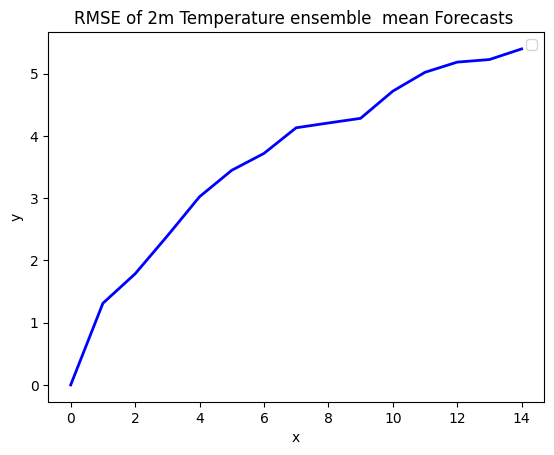

In [27]:
import matplotlib.pyplot as plt

# Example data
x = list(range(0, 15))
y = rmse_ens

# Create the plot
plt.plot(x, y, color="blue", linewidth=2)

# Add labels and title
plt.xlabel("x")
plt.ylabel("y")
plt.title("RMSE of 2m Temperature ensemble  mean Forecasts ")

# Show legend
plt.legend()

# Display the plot
plt.show()

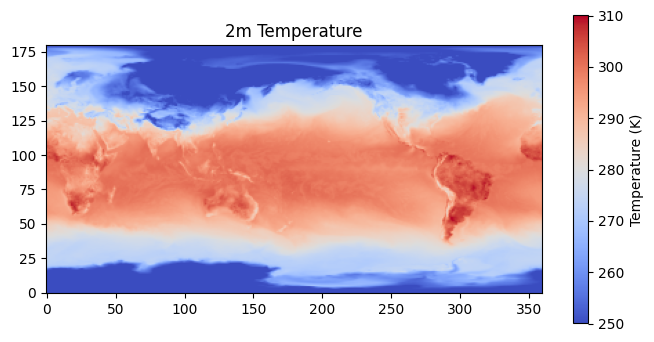

In [50]:
plt.figure(figsize=(8, 4))
plt.imshow(dataset, cmap="coolwarm", origin="lower",   vmin=250, vmax=310)
plt.colorbar(label="Temperature (K)")
plt.title("2m Temperature")
plt.show()

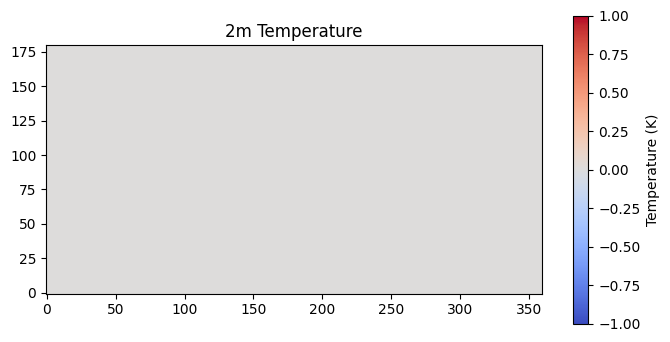

In [51]:
plt.figure(figsize=(8, 4))
plt.imshow(dataset-ds["2m_temperature"].values[0], cmap="coolwarm", origin="lower",   vmin=-1, vmax=1)
plt.colorbar(label="Temperature (K)")
plt.title("2m Temperature")
plt.show()

In [22]:
ds["temperature"].mean(dim = ["lat","lon"]).shape

(16, 17)

In [23]:
import os
if os.path.exists(gt_file):
    print("File exists!")
else:
    print("File not found.")

File exists!


In [24]:
#find the gorund truth file 

In [ ]:
dates[0].strftime("%Y%m%d%H")

'2018010100'

In [26]:
files = "/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_{}_ens_*.nc".format(dates[0].strftime("%Y%m%d%H"))

In [27]:
import glob
ens_files = glob.glob(files)

In [ ]:
#Get the ground truth 
file_era5 = "/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/2018_180x360.nc"
